# Dive into time-frequency domain!

In this lecture, you will be guided step by step, to see what is time-frequency (TF) domain, and how to search signal in TF domain.

Here we load the package `pycwb` and `wdm_wavelet`

In [38]:
import pycwb
from wdm_wavelet.wdm import WDM
import matplotlib.pyplot as plt
import numpy as np

Why we need unmodeled search?

 - Because we only have accurate enough models for limited sources


## Time domain, frequency domain, and time-frequency domain

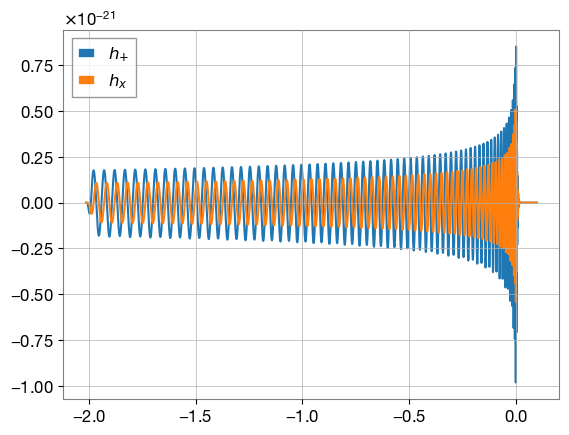

In [50]:
%matplotlib inline
from pycbc.waveform import get_td_waveform, utils

hp, hc = get_td_waveform(approximant="IMRPhenomTPHM",
                         mass1=20,
                         mass2=20,
                         spin1z=0.9,
                         spin2z=0.4,
                         inclination=1.23,
                         coa_phase=2.45,
                         distance=300,
                         delta_t=1.0/2048,
                         f_lower=20)
hp = utils.taper_timeseries(hp, tapermethod="startend")
hc = utils.taper_timeseries(hc, tapermethod="startend")
hp.plot(label="$h_\plus$")
hc.plot(label="$h_x$")
plt.legend()
plt.show()

In frequency domain

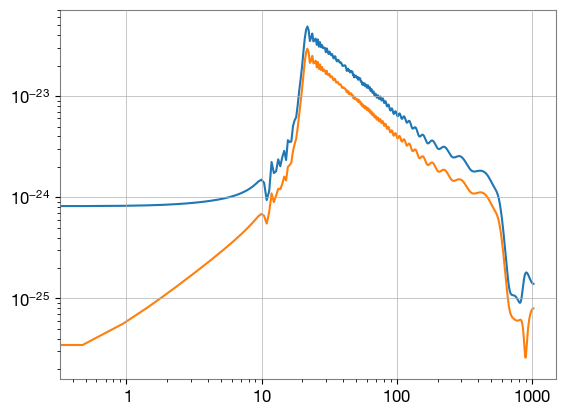

In [51]:
fp = hp.to_frequencyseries()
fc = hc.to_frequencyseries()

plt.loglog(fp.sample_frequencies, np.abs(fp))
plt.loglog(fc.sample_frequencies, np.abs(fc))

Now, let's move to time-frequency domain

(10.0, 800.0)

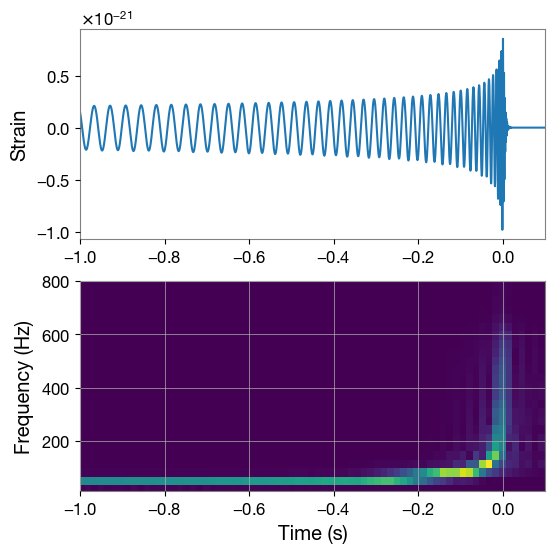

In [52]:
from wdm_wavelet.wdm import WDM

wdm = WDM(32, 64, 6, 10)
tf_map = wdm.t2w(hp)

fig, ax = plt.subplots(2,1, figsize=(6, 6))
ax[0].plot(hp.sample_times, hp)
ax[0].set_xlim(-1, 0.1)
ax[0].set_ylabel('Strain')
ax[0].grid(False)
tf_map.plot_energy(fig=fig, ax=ax[1], colorbar=False)
ax[1].set_xlim(-1, 0.1)
ax[1].set_ylim(10, 800)

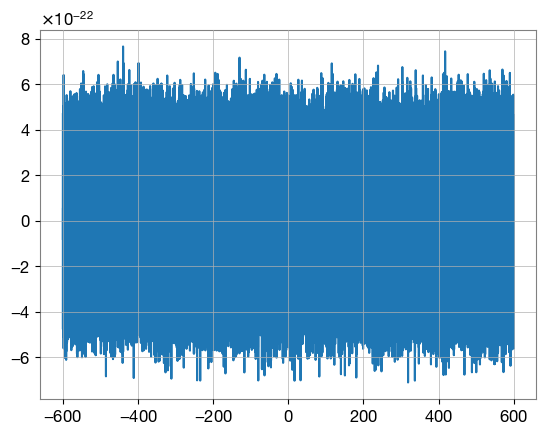

In [53]:
from pycwb.modules.read_data.mdc import generate_noise

noises = [generate_noise(sample_rate=2048, f_low=16,
                             duration=1200,
                             start_time=-600, seed=seed) for seed in [10, 20]]
noises[0].plot()

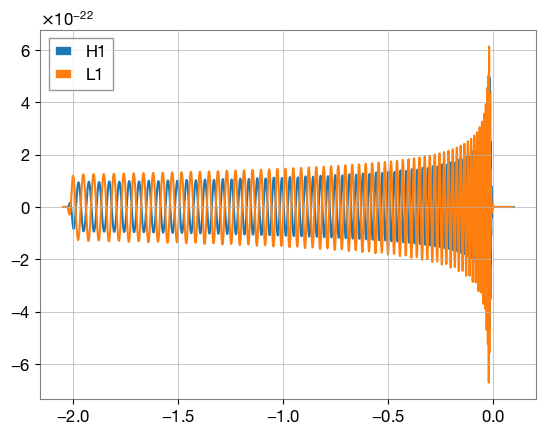

In [54]:
# Project signal to detector
from pycwb.modules.read_data.mdc import project_to_detector
right_ascension = 0
declination = 0
polarization = 0
ifos = ['H1', 'L1']
gps_end_time = 0

strain = project_to_detector(hp, hc, right_ascension, declination, polarization, ifos, gps_end_time)
strain[0].plot(label='H1')
strain[1].plot(label='L1')
plt.legend()
plt.show()

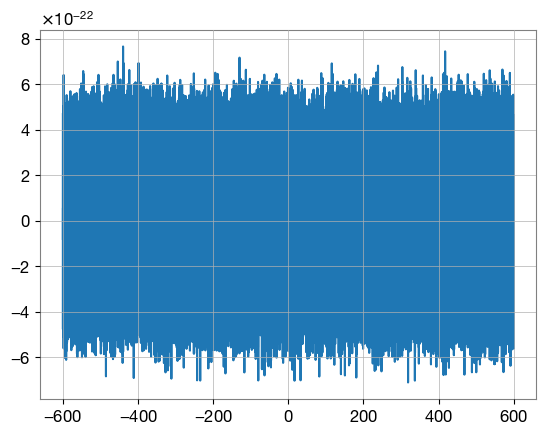

In [55]:
# Add signal to noise
noisy_strain = [
    noises[0].add_into(strain[0]), 
    noises[1].add_into(strain[0])
]

noisy_strain[0].plot()

(10.0, 800.0)

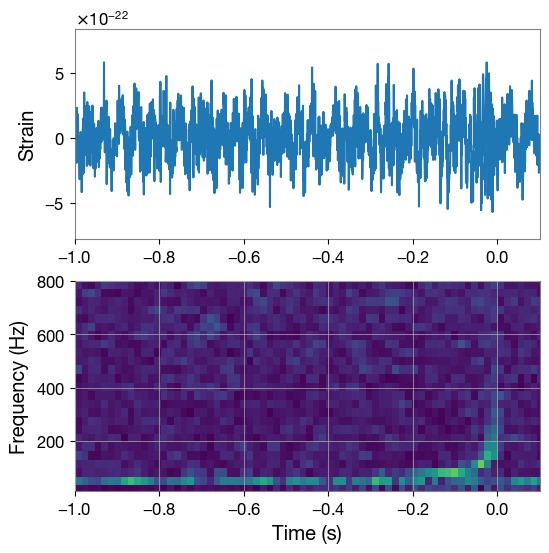

In [56]:
wdm = WDM(32, 64, 6, 10)
tf_map = wdm.t2w(noisy_strain[0])

fig, ax = plt.subplots(2,1, figsize=(6, 6))
ax[0].plot(noisy_strain[0].sample_times, noisy_strain[0])
ax[0].set_xlim(-1, 0.1)
ax[0].set_ylabel('Strain')
ax[0].grid(False)
tf_map.plot_energy(fig=fig, ax=ax[1], colorbar=False)
ax[1].set_xlim(-1, 0.1)
ax[1].set_ylim(10, 800)

In [57]:
from pycwb.config import Config

config = Config()
config.load_from_yaml('user_parameters.yaml')

In [58]:
from pycwb.modules.data_conditioning.whitening_cwb import whitening_cwb
from pycwb.modules.data_conditioning import data_conditioning

whiten_strains, nRMS = data_conditioning(config, noisy_strain)

# res = [whitening_cwb(config, h) for h in noisy_strain]
# whiten_strains, nRMS_list = zip(*res)

In [59]:
# wdm = WDM(32, 64, 6, 10)
# tf_map = wdm.t2w(whiten_strains[0])

# fig, ax = plt.subplots(2,1, figsize=(6, 6))
# ax[0].plot(whiten_strains[0].sample_times, whiten_strains[0])
# ax[0].set_xlim(-1, 0.1)
# ax[0].set_ylabel('Strain')
# ax[0].grid(False)
# tf_map.plot_energy(fig=fig, ax=ax[1], colorbar=False)
# ax[1].set_xlim(-1, 0.1)
# ax[1].set_ylim(10, 800)

(10.0, 800.0)

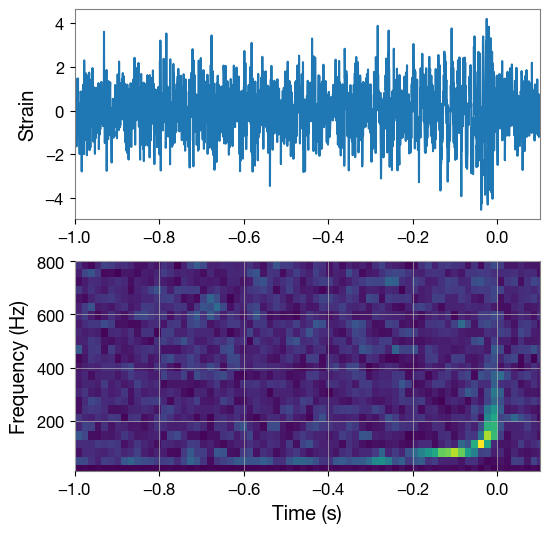

In [60]:
sliced_data = whiten_strains[0].data.time_slice(-2, 2)

wdm = WDM(32, 64, 6, 10)
tf_map = wdm.t2w(sliced_data)

fig, ax = plt.subplots(2,1, figsize=(6, 6))
ax[0].plot(sliced_data.sample_times, sliced_data)
ax[0].set_xlim(-1, 0.1)
ax[0].set_ylabel('Strain')
ax[0].grid(False)
tf_map.plot_energy(fig=fig, ax=ax[1], colorbar=False)
ax[1].set_xlim(-1, 0.1)
ax[1].set_ylim(10, 800)